In [210]:
import ast
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, AddHs, Draw
from rdkit.Chem.Draw import MolsToGridImage
import matplotlib.pyplot as plt
from pathlib import Path

drawer = Draw.rdMolDraw2D.MolDraw2DSVG(200, 200)
options = drawer.drawOptions()
options.legendFontSize = 24

# Imports

In [155]:
cwd = Path.cwd()
project_root = cwd.parent

full_descriptor_path = project_root / 'outputs/aqme/QDESCP/raw_csv_databases/Raw_QDESCP_full_descriptors.csv'
descriptors_full = pd.read_csv(full_descriptor_path)

smiles_path = project_root / 'outputs/aqme/smiles_aqme.csv'
smiles_df = pd.read_csv(smiles_path)
smiles_df['mol'] = smiles_df['SMILES'].apply(Chem.MolFromSmiles)

# Add hydrogens to the molecules
smiles_df['mol'] = smiles_df['mol'].apply(AddHs)

# Lists are saved as strings, so we need to convert them back to lists
def str_to_list(val):
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        try:
            return ast.literal_eval(val)
        except Exception:
            return val
    return val

descriptors_full = descriptors_full.map(str_to_list)

In [156]:
type(descriptors_full.iloc[6,6])

list

In [157]:
# Filter the df to only include columns containing list values
is_list_col = descriptors_full.map(lambda x: isinstance(x, list)).any()
descriptors_list = descriptors_full.loc[:, is_list_col]
descriptors_list = pd.concat([descriptors_full['code_name'], descriptors_list], axis=1, ignore_index=True)
descriptors_list.columns = descriptors_full.columns[:len(descriptors_list.columns)]

# Reorder alphabetically
descriptors_list = descriptors_list.sort_values('code_name').reset_index(drop=True)

# Remove the suffix from the code_name
descriptors_list['code_name'] = descriptors_list['code_name'].apply(lambda x: x.split('_')[0])

In [158]:
descriptors_list.head()

,code_name,Partial charge,Electrophil.,Nucleophil.,Radical attack,SASA,Buried volume,H bond with H2O,s proportion,p proportion,...,Nu_Electrophil.,Nu_Nucleophil.,Nu_Radical attack,Disp. coeff. C6,Born radii,Cone angle,Solid angle,FOD s proportion,FOD p proportion,FOD d proportion
0,Bifonazole,"[-0.022, 0.033, 0.0028, -0.034800000000000005,...","[-0.0039000000000000003, -0.0027, 0.0371, 0.01...","[0.0413, 0.0413, 0.0413, 0.0413, 0.0413, 0.041...","[0.011600000000000001, -0.0046, 0.028, 0.0102,...","[0.0013000000000000002, 0.0, 0.6408, 7.471, 11...","[0.4551, 0.7028, 0.7196, 0.7184, 0.5664, 0.525...","[0.0, 0.0, 0.0, -0.0005, -0.001, 0.0, 0.0, -0....","[1.447, 1.0311, 1.0647, 1.05, 1.0495, 1.0653, ...","[3.7184, 2.8586, 2.9961, 3.0025, 3.0073, 2.968...",...,"[-0.0049, -0.0034000000000000002, 0.0466, 0.01...","[0.0339, -0.0082, 0.024200000000000003, 0.0094...","[0.0145, -0.0058000000000000005, 0.0351, 0.012...","[21.668, 20.0241, 27.9605, 28.8667, 28.8303, 2...","[2.7504, 2.9049, 2.8816, 2.6395, 2.6135, 2.792...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0009000000000000001, 0.0, 0.0, 0.0, 0.0, 0....","[0.003, 0.001, 0.0108, 0.0061, 0.008, 0.0095, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Boscalid,"[-0.41590000000000005, 0.277, -0.161, 0.072000...","[0.1076, 0.0367, 0.0262, 0.0131, 0.0105, 0.024...","[0.0551, 0.0551, 0.0551, 0.0551, 0.0551, 0.055...","[0.09970000000000001, 0.0236, 0.0354, 0.021, 0...","[28.1914, 7.0661, 0.7103, 5.3004999999999995, ...","[0.31720000000000004, 0.4299, 0.6141, 0.7088, ...","[-0.002, -0.001, 0.0, 0.0, -0.001, -0.001, -0....","[1.724, 0.966, 1.422, 1.033, 1.058, 1.047, 1.0...","[4.8759, 2.5929, 3.91, 2.834, 3.004, 3.01, 3.0...",...,"[0.0796, 0.027200000000000002, 0.0194, 0.0097,...","[0.067, 0.0078000000000000005, 0.033, 0.021400...","[0.0738, 0.0175, 0.0262, 0.0155, 0.0097, 0.020...","[22.0064, 22.3137, 24.487, 26.3801, 29.158, 28...","[2.123, 2.567, 2.5019, 2.813, 2.578, 2.49, 2.4...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029, 0.014, 0.014, 0.011, 0.012, 0.00900000...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Caffeine,"[-0.441, 0.314, -0.117, 0.264, -0.436, -0.042,...","[0.0742, 0.008, 0.038900000000000004, 0.061, 0...","[0.061, 0.061, 0.061, 0.061, 0.061, 0.061, 0.0...","[0.0857, 0.0053, 0.0371, 0.0345, 0.1131, -0.02...","[30.9088, 9.0802, 1.52, 8.4802, 28.9089, 17.16...","[0.3524, 0.39940000000000003, 0.589, 0.6178, 0...","[-0.002, -0.001, 0.0, -0.001, -0.002, 0.0, 0.0...","[1.721, 0.9380000000000001, 1.444, 0.944000000...","[4.909, 2.528, 3.854, 2.69, 4.948, 2.953000000...",...,"[0.0979, 0.0105, 0.051300000000000005, 0.0804,...","[0.1282, 0.0023, 0.0455, 0.0105, 0.1282, -0.02...","[0.1131, 0.007, 0.049, 0.0455, 0.1492, -0.0303...","[22.509, 21.668, 23.549, 22.553, 22.409, 21.46...","[2.101, 2.5789999999999997, 2.466, 2.575, 2.09...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.007, 0.002, 0.005, 0.011, 0.016, 0.001, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Camptothecin,"[-0.4617, 0.2529, -0.059800000000000006, 0.010...","[0.0935, 0.0098, 0.0771, 0.0453, 0.0, 0.0081, ...","[0.0492, 0.0492, 0.0492, 0.0492, 0.0492, 0.049...","[0.1212, 0.0114, 0.0704, 0.033800000000000004,...","[34.0865, 8.1127, 3.1121, 1.682, 0.0, 19.2302,...","[0.3658, 0.3876, 0.5919, 0.6979000000000001, 0...","[-0.003, -0.001, 0.0, 0.0, 0.0, -0.001, 0.0, 0...","[1.728, 0.974, 1.07, 1.0782, 1.0421, 1.6981000...","[4.895, 2.578, 3.1048, 2.9351000000000003, 2.7...",...,"[0.047900000000000005, 0.005, 0.0395, 0.023200...","[0.0763, 0.0059, 0.0327, 0.0115, 0.005, 0.0257...","[0.0621, 0.0059, 0.0361, 0.0173, 0.0025, 0.014...","[22.95, 22.7528, 29.485, 27.7697, 18.6935, 21....","[2.1017, 2.6

In [159]:
smiles_df.head()

,SMILES,code_name,mol
0,N1(C(C2=CC=C(C3=CC=CC=C3)C=C2)C4=CC=CC=C4)C=CN=C1,Bifonazole,<rdkit.Chem.rdchem.Mol object at 0x00000266CE7...
1,O=C(NC1=CC=CC=C1C2=CC=C(Cl)C=C2)C3=CC=CN=C3Cl,Boscalid,<rdkit.Chem.rdchem.Mol object at 0x00000266CE7...
2,O=C(N(C1=O)C)N(C2=C1N(C=N2)C)C,Caffeine,<rdkit.Chem.rdchem.Mol object at 0x00000266CE7...
3,O=C1C2=C([C@@](O)(CC)C(OC2)=O)C=C(N1C3)C(C3=C4...,Camptothecin,<rdkit.Chem.rdchem.Mol object at 0x00000266CE7...
4,CN/C(NCCSCC1=C(C)NC=N1)=N\C#N,Cimetadine,<rdkit.Chem.rdchem.Mol object at 0x00000266CE7...


In [160]:
print(descriptors_list.columns)

Index(['code_name', 'Partial charge', 'Electrophil.', 'Nucleophil.',
       'Radical attack', 'SASA', 'Buried volume', 'H bond with H2O',
       's proportion', 'p proportion', 'd proportion', 'Coord. numbers',
       'Polariz. alpha', 'FOD', 'Dispersion', 'Pyramidalization',
       'Pyramidaliz. volume', 'fukui+', 'fukui-', 'fukui0', 'dual descrip.',
       'softness+', 'softness-', 'softness0', 'Rel. nucleophilicity',
       'Rel. electrophilicity', 'GC Dual Descrip.', 'Mult. descrip.',
       'Nu_Electrophil.', 'Nu_Nucleophil.', 'Nu_Radical attack',
       'Disp. coeff. C6', 'Born radii', 'Cone angle', 'Solid angle',
       'FOD s proportion', 'FOD p proportion', 'FOD d proportion'],
      dtype='object')


## Indexing investigations

In [161]:
mol = smiles_df['mol'][0]
num_atoms = mol.GetNumAtoms()
len_descriptors = len(descriptors_list.iloc[0,3])
print(f'Number of atoms for {smiles_df.loc[0, 'code_name']} in mol is {num_atoms}')
print(f'Length of {descriptors_list.loc[0, 'code_name']} descriptor lists is {len_descriptors}')  # Exclude 'code_name'

Number of atoms for Bifonazole in mol is 42
Length of Bifonazole descriptor lists is 42


In [174]:
def get_max_index(df, col_name):
    """Get the maximum index from the list in the specified column."""
    values = df[col_name].apply(lambda x: [int(np.argmax(x))] if isinstance(x, list) and len(x) > 0 else [])
    return values.tolist()

Highlight lists: [[22], [13], [0], [0], [6], [20], [4], [19], [0], [10], [9], [15], [6], [10], [11], [11], [7], [11], [8], [15], [11], [16], [0], [15], [12], [5], [24], [0], [20], [21], [13]]


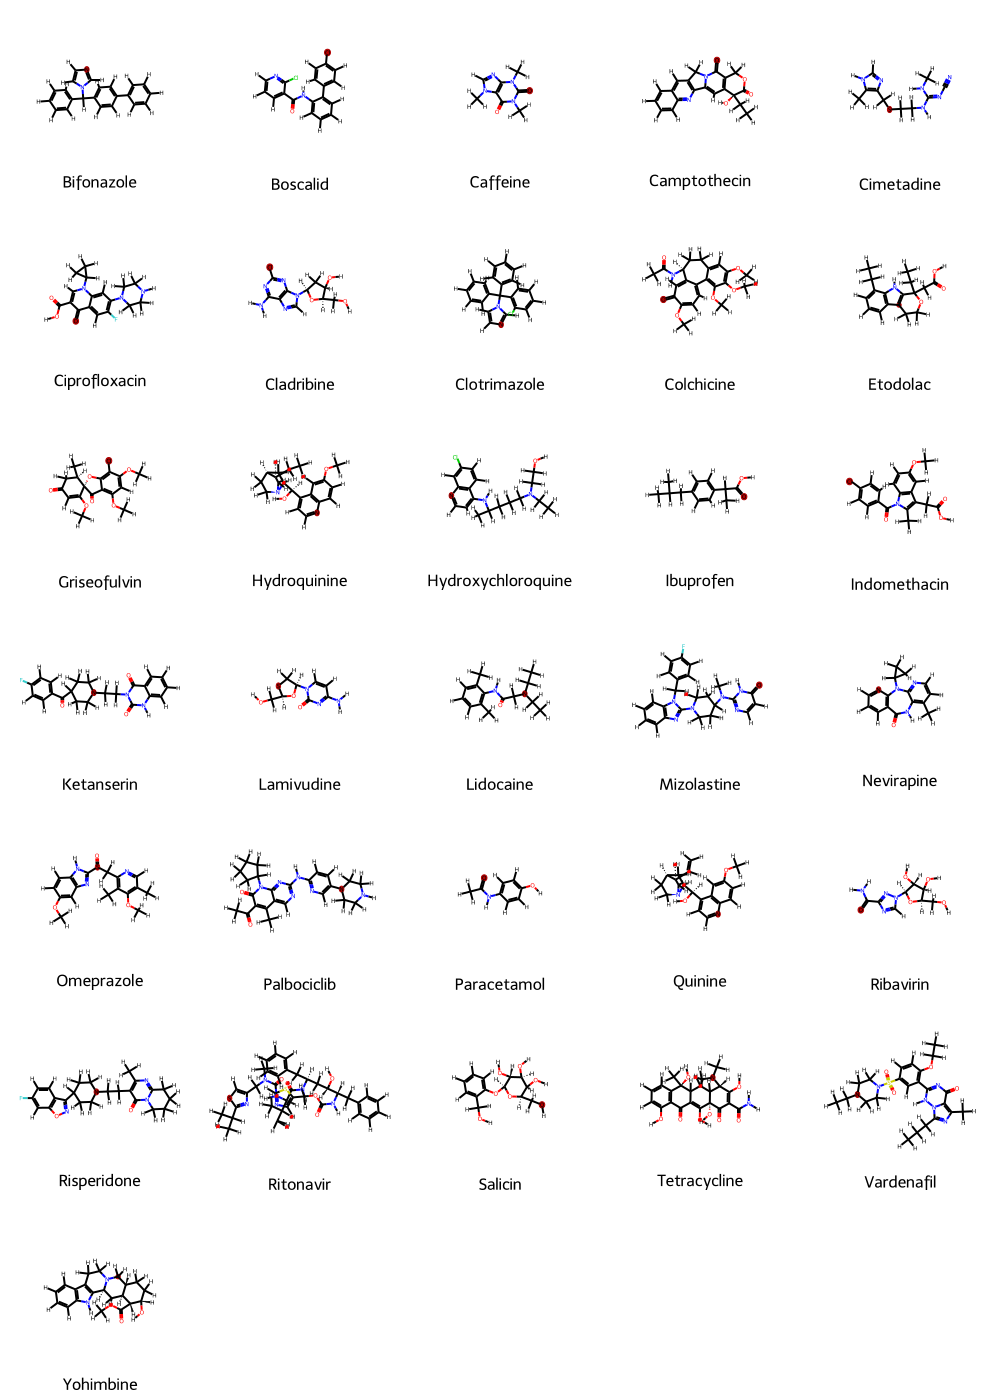

In [213]:
# Highlight the maximum index in the specified descripptor
value_to_highlight = 'Nu_Nucleophil.'

if value_to_highlight not in descriptors_list.columns:
    raise ValueError(f"Column '{value_to_highlight}' not found in descriptors_list.")

highlight_lists = get_max_index(descriptors_list, value_to_highlight)
print(f'Highlight lists: {highlight_lists}')

deep_red = (0.7, 0, 0)  # Example deep red color
highlight_colors = [{lst[0]: deep_red} for lst in highlight_lists]

img = MolsToGridImage(
    smiles_df['mol'].tolist(),
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=smiles_df['code_name'].tolist(),
    useSVG=True,
    highlightAtomLists=highlight_lists,
    highlightAtomColors=highlight_colors  # This draws a colored circle around the atom
)
img

Atoms selected as the most nucleophilic tended to be heteroatoms. Potentially more useful would be information about the most nucleophilic aromatic carbon bonded to a hydrogen...

In [176]:
def aromatic_carbons_with_CH(mol):
    return [
        idx for idx in range(mol.GetNumAtoms())
        if (
            mol.GetAtomWithIdx(idx).GetSymbol() == 'C' # Carbon atom
            and mol.GetAtomWithIdx(idx).GetIsAromatic() # Aromatic carbon
            and mol.GetAtomWithIdx(idx).GetTotalNumHs(includeNeighbors=True) > 0 # Aromatic carbon a bonded hydrogen
        )
    ]

Aromatic carbons with CH in Ritonavir: [6, 7, 8, 9, 10, 23, 37, 38, 39, 40, 41, 46, 48]


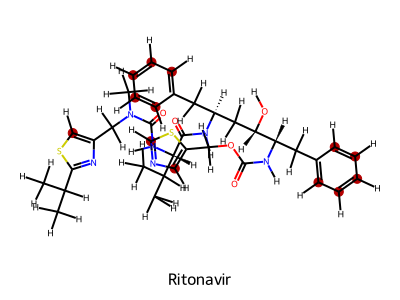

In [192]:
mol_index = 26

mol = smiles_df['mol'][mol_index]
atom_indices = aromatic_carbons_with_CH(mol)
print(f'Aromatic carbons with CH in {smiles_df.loc[mol_index, "code_name"]}: {atom_indices}')

atom_labels = {idx: str(idx) for idx in atom_indices}
img = Draw.MolToImage(
    mol,
    size=(400, 300),
    legend=smiles_df.loc[mol_index, "code_name"],
    highlightAtoms=atom_indices,  
    highlightColor=(0.7, 0, 0)           
)
img

In [203]:
# Extract the values corresponding to the highlighted atoms
def extract_max_ch_value(mol, values, n_top=2):
    atom_indices = aromatic_carbons_with_CH(mol)
    ch_values = [values[idx] for idx in atom_indices]
    maxs = np.argsort(ch_values)[-n_top:][::-1]
    return [atom_indices[i] for i in maxs]

def get_max_ch_index(df, col_name):
    indices = []
    for i, row in df.iterrows():
        index = extract_max_ch_value(smiles_df.loc[i,'mol'], row[col_name])
        indices.append(index)
    return indices

Highlight lists: [[21, 10], [15, 14], [10], [12, 24], [12], [7, 17], [9], [18, 12], [25, 14], [4, 3], [6], [13, 22], [4, 10], [5, 12], [15, 20], [22, 20], [13, 12], [2, 4], [29, 30], [17, 11], [22, 18], [12, 15], [6, 10], [13, 22], [7], [17, 20], [8, 6], [15, 13], [4, 2], [13, 14], [7, 8]]


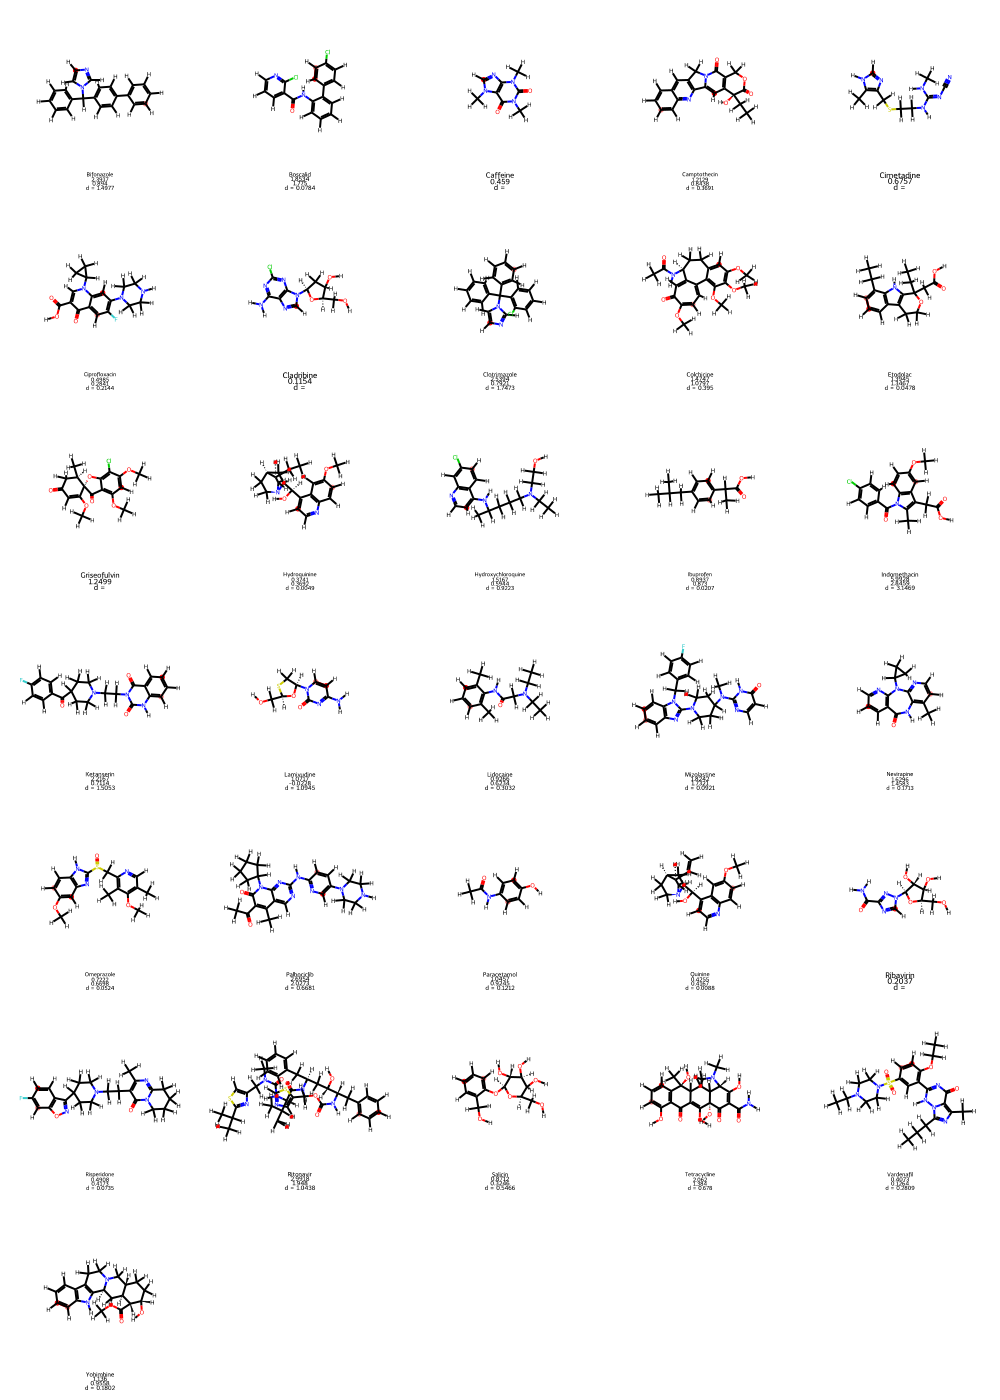

In [219]:
# Highlight the maximum index in the specified descripptor
value_to_highlight = 'Rel. nucleophilicity'

if value_to_highlight not in descriptors_list.columns:
    raise ValueError(f"Column '{value_to_highlight}' not found in descriptors_list.")

highlight_lists = get_max_ch_index(descriptors_list, value_to_highlight)
print(f'Highlight lists: {highlight_lists}')

color = (1, 0, 0)
highlight_colors = [{lst[0]: color} for lst in highlight_lists]

max_values = [descriptors_list.loc[x, value_to_highlight][lst[0]] for x, lst in enumerate(highlight_lists)]
second_max_values = [descriptors_list.loc[x, value_to_highlight][lst[1]] if len(lst) > 1 else None for x, lst in enumerate(highlight_lists)]

lables = [
    f'{x}\n{np.round(y, 5)}\n{np.round(z, 5) if z is not None else ""}\nd = {np.round(abs(y - z), 5) if z is not None else ""}'
    for x, y, z in zip(smiles_df['code_name'], max_values, second_max_values)
]

img = MolsToGridImage(
    smiles_df['mol'].tolist(),
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=lables,
    useSVG=True,
    highlightAtomLists=highlight_lists,
    highlightAtomColors=highlight_colors,
    #removeHs=True
)
img

Atoms selected tended to be the most reactive within the investigated system, and could potentially lead to regioselectivity predictions. When selecting the top 2, the site of reactivity in the formation of major products was encapsulated for all successful substrates, with the exception of ritonavir, where the phenyl moiety was selected as being more nucleophilic than the thioazole, and colchicine, where the propone moiety was selected as being more nucleophilic than the phenyl